# Фактори за академичния успех на учениците
## Анализ на данни за представянето по математика

**Автор:** Славена Славова
**Дата:** 14 май 2026 г.

---

### За какво е този анализ?

Този анализ цели да анализира какви са причините да има много умни деца в училище и такива, които се представят значително по-зле. Ще разберем дали всичко опира до това дали са **"умни" или просто "мързеливи"** учениците **и какво реално се крие зад ниските резултати?**   

Данните от това изследване обхващат ученици от ***две училища в Португалия***. Те ни позволяват да погледнем каква е ситуациата в клас. Как семейната среда, социалният живот и свободното време оказват влияние. И колко точно е от значение *образованието на родителите*? Има ли брой на *отсъствията*, след който успехът става невъзможен? Може ли *социалният живот* (алкохол и излизания) *да бъде компенсиран с* повече време за *учене*?   

В този анализ ще потъсим кои **фактори определят бъдещето на един ученик.**

---

### Какво очакваме да открием?

Първо **предполагаме**, за да проверим по-късно дали сме прави.

**Хипотеза 1:** Учениците, чиито родители имат висше образование и ги подкрепят, показват по-високи резултати.
*Защо:* Семейната среда и подкрепата често са решаващи за мотивацията, а най-добрата за едно дете е именно *личният пример*.

**Хипотеза 2:** Редовната консумация на алкохол през седмицата влияе отрицателно на успеха.
*Защо:* Консумацията на алкохол води до лоша концентрация и прави почти *невъзможно протичането на нормален учебен процес*, в последствие се понижават  и оценките.

**Хипотеза 3:** Учениците с повече от 10 отсъствия имат значително по-нисък шанс за оценка > 16.
*Защо:* Пропуснатият материал по математика се наваксва трудно и води до *"дупки" в знанията*.

**Хипотеза 4:** Седмичното време за учене има пряка връзка с това, колко пъти е късан ученикът по математика. *Защо:* Това е предмет, който за един нормален ученик изисква *повече време за учене* и постоянство, за да се усвои добре.

---

**Данни:** [Student Performance Dataset](https://archive.ics.uci.edu/dataset/320/student+performance) (UCI Machine Learning Repository) - информация за 395 ученици.


---
# Част I: Какво знаем за тези ученици?

Нека заредим данните и видим какво съдържат.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_raw = pd.read_csv('/content/student-mat.csv', sep=';')
print(f'Имаме данни за {df_raw.shape[0]} ученици с {df_raw.shape[1]} характеристики.')
df_raw.head(10)


Имаме данни за 395 ученици с 33 характеристики.


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


Всеки ред е един ученик. Колоните ни казват:

| Колона | Какво означава | Пример |
|--------|---------------|--------|
| school | училището, в което учи | '**GP**' - Gabriel Pereira; '**MS**' - Mousinho da Silveira |
| sex | пол | '**F**' - female; '**M**' - male |
| age | възраст | от 15 до 22 |
| address | тип на адреса на ученика | '**U**' - urban; '**R**' - rural |
| famsize | големина на семейството |  '**LE3**' - less or equal to 3; '**GT3**' - greater than 3 |
| Pstatus | статус на родителите | '**T**' - living together; '**A**' - apart |
| Medu | образование на майката | **0** - none; **1** - primary education (4th grade); **2** - 5th to 9th grade; **3** - secondary education; **4** - higher education |
| Fedu | образование на бащата | **0** - none; **1** - primary education (4th grade); **2** - 5th to 9th grade; **3** - secondary education; **4** - higher education |
| Mjob | работа на майката | '**teacher**'; '**health**' - care related; '**services**' - civil services/administrative/police; '**at_home**'; '**other**' |
| Fjob | работа на бащата | '**teacher**'; '**health**' - care related; '**services**' - civil services/administrative/police; '**at_home**'; '**other**' |
| reason | причина за избор на училището | close to '**home**'; school '**reputation**'; '**course**' preference; '**other**' |
| guardian | настойник | '**mother**'; '**father**'; '**other**' |
| traveltime | време за път от вкъщи до училище | **1** - под 15 мин; **2** - 15 до 30 мин; **3** - 30 мин до 1 час; **4** - над 1 час |
| studytime | седмично време за учене | **1** - под 2 часа; **2** - 2 до 5 часа; **3** - 5 до 10 часа; **4** - над 10 часа |
| failures | колко пъти ученикът е "късан" по математика | **0**; **1**; **2**; **3**; **4** - 4 или повече|
| schoolsup  | допълнителна образователна подкрепа от училището | '**yes**'; '**no**' |
| famsup | образователна подкрепа от семейството | '**yes**'; '**no**' |
| paid | допълнителни платени часове по предмета | '**yes**'; '**no**' |
| activities | извънкласни дейности | '**yes**'; '**no**' |
| nursery | дали ученикът е посещавал детска градина | '**yes**'; '**no**' |
| higher | желание за завършване на висше образование | '**yes**'; '**no**' |
| internet | достъп до интернет вкъщи | '**yes**'; '**no**' |
| romantic | наличие на романтична връзка | '**yes**'; '**no**' |
| famrel | качество на семейните отношения | от **1** - много лоши до **5** - отлични |
| freetime | свободно време след училище | от **1** - много малко до **5** - много голямо |
| goout | излизане с приятели | от **1** - много рядко до **5** - много често |
| dalc | консумация на алкохол през работни дни | от **1** - много ниска до **5** - много висока |
| walc | консумация на алкохол през уикенда | от **1** - много ниска до **5** - много висока |
| health | текущо здравословно състояние | от **1** - много лошо до **5** - много добро |
| absences | брой отсъствия от училище | от **0** до **93** |
| G1 | оценка от първия учебен срок | от **0** до **20** |
| G2 | оценка от втория учебен срок | от **0** до **20** |
| G3 | крайна оценка | от **0** до **20** |

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
df_raw.describe().round(1)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.0,395.0,395.0,395.0,395.0,395.0,395.0,395.0,395.0,395.0,395.0,395.0,395.0,395.0,395.0,395.0
mean,16.7,2.7,2.5,1.4,2.0,0.3,3.9,3.2,3.1,1.5,2.3,3.6,5.7,10.9,10.7,10.4
std,1.3,1.1,1.1,0.7,0.8,0.7,0.9,1.0,1.1,0.9,1.3,1.4,8.0,3.3,3.8,4.6
min,15.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,3.0,0.0,0.0
25%,16.0,2.0,2.0,1.0,1.0,0.0,4.0,3.0,2.0,1.0,1.0,3.0,0.0,8.0,9.0,8.0
50%,17.0,3.0,2.0,1.0,2.0,0.0,4.0,3.0,3.0,1.0,2.0,4.0,4.0,11.0,11.0,11.0
75%,18.0,4.0,3.0,2.0,2.0,0.0,5.0,4.0,4.0,2.0,3.0,5.0,8.0,13.0,13.0,14.0
max,22.0,4.0,4.0,4.0,4.0,3.0,5.0,5.0,5.0,5.0,5.0,5.0,75.0,19.0,19.0,20.0


In [ ]:
df_raw.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

### Какво забелязваме веднага?

След използването на `.info()` и `.describe()`, откриваме няколко важни неща:

1. **Няма празни данни:** Всички 33 колони имат по 395 записа без нито една липсваща стойност (0 non-null). Това означава, че разполагаме с  "чист" първоначален набор от данни.  

2. **Финалната оценка (G3):** Докато средната оценка е около 10.4, виждаме, че минималната стойност е 0. Статистиката показва, че има група ученици с нулев резултат, което вероятно означава отпадане или неявяване на изпит.

3. **Екстремни стойности за отсъствията:** Средния брой отсъствия **mean** е 5.7. В същото време максимумът **max** е 75, което означава, че има няколко ученици със сравнително повече отсъствия.На тези крайни стойности (outliers) трябва да им се обърне внимание при почистването, за да не изкривят изводите.

4. **Възрастов диапазон:** Учениците са на възраст между 15 и 22 години, като средната възраст е близо 17 години. Това показва, че имаме и по-възрастни ученици, които може би са повтаряли класове.

---


---
# Част II: Подготовка на данните

Данните са пълни, но не са в удобен формат за анализ. За да проверим хипотезите си, трябва:
1. Да проверим за дублирани редове.
2. Да решим как да третираме екстремните стойности при отсъствията.
3. Да превърнем текстовите колони в числови.

## Имаме ли дублирани редове?

In [ ]:
# Проверка за дублирани редове
duplicates = df_raw.duplicated().sum()
print(f'Брой дублирани редове: {duplicates}')

Брой дублирани редове: 0


Липсват дублирани редове. Затова можем да създадем копие на първоначалния dataset `df_raw`, върху което ще работим.

In [ ]:
# Създаваме копие
df = df_raw.copy()

In [ ]:
# Визуализираме го
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


## Какво ще правим екстремните стойности при отсъствията?




Много е важно да не изтрием тези ученици, защото всеки запис е важен за нас. Вместо това ще използваме ***IQR метода*** за стойностите на `absences`, за да сложим граници. Така ще имаме същия брой ученици, но без екстремни стойности, които да ни изкривят графиките и изследването.


---

IQR методът е стандартният метод за откриване на outliers. При него стойности извън `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]` се считат за необичайни.

**Междуквартилният размах** *IQR* показва обхвата на средните 50% от данните. `IQR = Q3 - Q1`.

**Минимална стойност** е най-ниската стойност в набора от данни.

**Q1** е стойността под която се намират **25%** от данните.

**Q2** съвпада с **медианата** и разделя набора на две равни части.

**Q3** е стойността под която се намират **75%** от данните.

**Максималната стойност** е най-високата стойност в набора от данни.

In [ ]:
# Изчисляваме квартилите и IQR
abs_q1 = df['absences'].quantile(0.25)
abs_q3 = df['absences'].quantile(0.75)
print(f'Q1 e: {abs_q1} и под нея се намират 25% от данните')
print(f'Q3 e: {abs_q3} и под нея се намират 75% от данните')

abs_iqr = abs_q3 - abs_q1
print(f'IQR e: {abs_iqr} и това е обхвата на средните 50% от данните')

# Изчисляваме границите
upper = abs_q3 + 1.5 * abs_iqr
lower = abs_q1 - 1.5 * abs_iqr
print(f'Минималната стойност е: {lower}')
print(f'Максималната стойност е: {upper}')

# Преброяваме outliers преди промяната
outliers = ((df['absences']<lower) | (df['absences']>upper)).sum()
print(f'Имаме {outliers} стойности, които са извън тези граници')


Q1 e: 0.0 и под нея се намират 25% от данните
Q3 e: 8.0 и под нея се намират 75% от данните
IQR e: 8.0 и това е обхвата на средните 50% от данните
Минималната стойност е: -12.0
Максималната стойност е: 20.0
Имаме 15 стойности, които са извън тези граници


In [ ]:
# Преди промените
mean_before = df['absences'].mean()
std_before = df['absences'].std()

Ще използваме `.clip()`, за да ограничим стойностите.

In [ ]:
# Прилагаме промените като презаписваме данните в колоната
df['absences'] = df['absences'].clip(lower=lower, upper=upper)

Каква **промяна** наблюдаваме при средната стойност и стандартното отклонение след приложените ограничения?

In [ ]:
# Проверка на резултатите след ограниченията
mean_after = df['absences'].mean()
std_after = df['absences'].std()

print(f'Средната стойност преди: {mean_before:.2f} и след: {mean_after:.2f}')
print(f'Стандартното отклонение преди: {std_before:.2f} и след: {std_after:.2f}')

Средната стойност преди: 5.71 и след: 5.19
Стандартното отклонение преди: 8.00 и след: 5.69


### Какво означават резултатите?

**Средният брой отсъствия намаля**, което потвърждава, че 15-те екстремни стойности (outliers) са изкривявали изследването.

*Стандартното отклонение* също спадна. Това е важно, защото намаляването на "шума" в данните ще ни позволи да открием по-правилни закономерности по-късно.

## Какво се случва с текстовите колони?


При необходимост превръщаме категории за по-късен анализ от **текстови в числови**.

За хипотеза 1 ще използваме `famsup` - дали ученикът получава образователна подкрепа от семейството - 'yes' или 'no'

Превръщаме я в: `'yes' = 1`  `'no' = 0 `

Така с формули можем да изчислим какво влияние имат върху крайната оценка.


In [ ]:
# Кодираме подрепата от родителите като число (за корелационен анализ)
df['famsup_code'] = df['famsup'].map({'no': 0, 'yes': 1})

In [ ]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,famsup_code
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,0
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,4,4,5,4,11,9,9,9,1
391,MS,M,17,U,LE3,T,3,1,services,services,...,4,5,3,4,2,3,14,16,16,0
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,3,3,3,3,3,10,8,7,0
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,1,3,4,5,0,11,12,10,0


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   school       395 non-null    object
 1   sex          395 non-null    object
 2   age          395 non-null    int64 
 3   address      395 non-null    object
 4   famsize      395 non-null    object
 5   Pstatus      395 non-null    object
 6   Medu         395 non-null    int64 
 7   Fedu         395 non-null    int64 
 8   Mjob         395 non-null    object
 9   Fjob         395 non-null    object
 10  reason       395 non-null    object
 11  guardian     395 non-null    object
 12  traveltime   395 non-null    int64 
 13  studytime    395 non-null    int64 
 14  failures     395 non-null    int64 
 15  schoolsup    395 non-null    object
 16  famsup       395 non-null    object
 17  paid         395 non-null    object
 18  activities   395 non-null    object
 19  nursery      395 non-null    

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


След извършените промени dataset-ът съдържа 395 реда, 34 колони и няма липсващи стойности.

---
# Част III: Кой успява?


За целта първо се запознаваме с тяхната скала за оценяване:

| Оценка | Ниво |
|--------|------|
| 18–20 | Отличен |
| 16–17 | Много добър |
| 14–15 | Добър |
| 10–13 | Задоволителен |
| 0–9   | Слаб |

### Хипотеза 1: Образованието на родителите и семейната подкрепа


Нека видим числата.


Ще групираме по ниво на образование на родителите и крайна оценка, за да преценим реално каква е връзката между тях.

In [ ]:
fedu_g3=df.groupby('Fedu')['G3'].agg(['mean', 'count']).round(2)
fedu_g3.columns = ['Средна G3', 'Брой ученици']
print('Средна крайна оценка според образованието на БАЩАТА:')
fedu_g3

Средна крайна оценка според образованието на БАЩАТА:


,Средна G3,Брой ученици
Fedu,,
0,13.00,2
1,9.16,82
2,10.26,115
3,10.66,100
4,11.36,96


Учениците, чиито бащи нямат образовние, се справят средно най-добре. Най-високи след това са резултатите на ученици с бащи, които са завършили висше, следвани от средно, основно и начален етап. Наблюдаваме разлика от 1.64 точки между най-ниското и най-високото образование.

In [ ]:
medu_g3=df.groupby('Medu')['G3'].agg(['mean', 'count']).round(2)
medu_g3.columns = ['Средна G3', 'Брой ученици']
print('Средна крайна оценка според образованието на МАЙКАТА:')
medu_g3


Средна крайна оценка според образованието на МАЙКАТА:


,Средна G3,Брой ученици
Medu,,
0,13.00,3
1,8.68,59
2,9.73,103
3,10.30,99
4,11.76,131


При майките ситуацията е подобна, като средните резултати се доближават до предходните. Наблюдаваме леко покачване в средната оценка на децата с родители висшисти.

In [ ]:
mother_sup = pd.pivot_table(
    df,
    index='Medu',
    columns='famsup',
    values='G3',
    aggfunc='mean').round(2)
print('Средна G3 по образование на майката и семейна подкрепа:')
mother_sup

Средна G3 по образование на майката и семейна подкрепа:


famsup,no,yes
Medu,,
0,15.00,9.00
1,8.47,8.93
2,10.16,9.40
3,11.25,9.76
4,12.24,11.57


Семейната подкрепа `famsup` не променя подредбата. Наблюдаваме, че децата, чиито майки са без образовяние и не ги подкрепят, имат средна оценка 15, която вече е оценка *Добър*.

### Хипотеза 2: Консумацията на алкохол и успехът

По сходен начин ще разгледаме колоните консумация на алкохол през работни дни `dalc` и `G3`.

Консумация:

1 - много ниска    
2 - ниска    
3 - средна   
4 - висока     
5 - много висока  

In [ ]:
dalc_g3 = df.groupby('Dalc')['G3'].agg(['mean', 'count']).round(2)
dalc_g3.columns = ['Средна G3', 'Брой ученици']
print('Средна крайна оценка по консумация на алкохол в работни дни (Dalc):')
dalc_g3

Средна крайна оценка по консумация на алкохол в работни дни (Dalc):


,Средна G3,Брой ученици
Dalc,,
1,10.73,276
2,9.25,75
3,10.50,26
4,9.89,9
5,10.67,9


Групирани така числата означават следното:
- най-добре се справят учениците, които пият най-малко и са най-много на брой 276
- след тях са тези, които пият най-често, но са само 9
- по средата са тези, които пият средно

Но общо погледнато тези оценки изглеждат почти еднакви.


Ще обърнем внимание и на l,връзката между алкохола и провалите, които са претърпели учениците - колко пъти са ги късали `failures`

In [ ]:
alc_fail = pd.crosstab(index=df['Dalc'],
                      columns=df['failures'],
                      normalize='index').round(3) * 100
print('% ученици по ниво на алкохол и брой късания:')
alc_fail.round(1)

% ученици по ниво на алкохол и брой късания:


failures,0,1,2,3
Dalc,,,,
1,84.1,10.5,2.5,2.9
2,66.7,16.0,10.7,6.7
3,65.4,23.1,3.8,7.7
4,66.7,22.2,11.1,0.0
5,77.8,11.1,0.0,11.1


Докато средните оценки при консумацията на алкохол се доближаваха, процентно виждаме, че пътите, в които са били скъсани се различават.

Най-ниската консумация на алкохол свързваме с 0 късания - изключително голям процент 84%.

Също най-често късаните 4 пъти са и най-често пиещи.
Изненадата идва тук:
Тези, които пият най-често са втори по 0 късания.
Стигаме до заключението, че не винаги алкохолът е директната причина за лоши резултати.


### Хипотеза 3: Многото отсъствия и шансът за висока оценка

Създаваме нова колона `high_absences`

Резултатът е колона с 1 за над 10 отсъствия и 0 за под или равно на 10.
Проверката се случва с булев израз: `df['absences'] > 10` и се записва като тип `int`.

In [ ]:
df['high_absences'] = (df['absences'] > 10).astype(int)
print(df['high_absences'].value_counts())

high_absences
0    329
1     66
Name: count, dtype: int64


Създаваме колона `high_grade` за висока крайна оценка, равна или по-голяма от 16 с резлутат 1, ако е вярно

In [ ]:
df['high_grade'] = (df['G3'] >= 16).astype(int)

Създаваме кръстосана таблица в проценти

In [ ]:
abs_grade_pct = pd.crosstab(index=df['high_absences'],
                            columns=df['high_grade'],
                            normalize='index').round(3) * 100

abs_grade_pct.index = ['До 10 отсъствия', 'Над 10 отсъствия']
abs_grade_pct.columns = ['Оценка < 16', 'Оценка >= 16']

print('Шанс за висока оценка (G3 >= 16) спрямо отсъствията в %:')
abs_grade_pct

Шанс за висока оценка (G3 >= 16) спрямо отсъствията в %:


,Оценка < 16,Оценка >= 16
До 10 отсъствия,89.1,10.9
Над 10 отсъствия,93.9,6.1


Резлутатите ни показват, че учениците с **до 10** отсътвия имат осезаемо **по-голям шанс** да постигнат много добра или отлична оценка, за разлика от тези с над 10.

Въпрос: Как отсъствията влияят върху успеха?

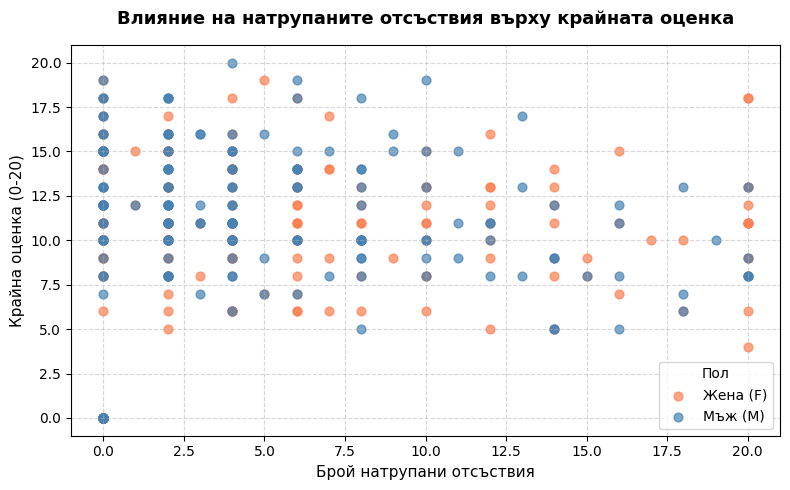

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

girls = df[df['sex'] == 'F']
boys = df[df['sex'] == 'M']

ax.scatter(girls['absences'], girls['G3'], color='coral', alpha=0.7, s=40, label='Жена (F)')
ax.scatter(boys['absences'], boys['G3'], color='steelblue', alpha=0.7, s=40, label='Мъж (M)')

ax.set_title('Влияние на натрупаните отсъствия върху крайната оценка', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Брой натрупани отсъствия', fontsize=11)
ax.set_ylabel('Крайна оценка (0-20)', fontsize=11)
ax.legend(title='Пол', fontsize=10)

ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Наблюдаваме, че най-високите резултати са на хора с по-малко отсъствия.
Присъствието в класната стая е много важно за ученето.


Първа потвърдена хипотеза! Хипотеза 3!

Пропуските в материала оказват влияние.[link text](https://)

### Хипотеза 4: Време за учене и брой късания

Ще сравним `studytime` време за учене от 1 до 4 и `failures` брой предишни късания от 0 до 3.


studytime:

1 - под 2 часа;

2 - 2 до 5 часа;

3 - 5 до 10 часа;

4 - над 10 часа

Изчисляваме средния брой провали за всяка категория време за учене

In [ ]:
study_fail = df.groupby('studytime')['failures'].mean().round(2)
print('Връзка между времето за учене и средния брой провали:')
study_fail

Връзка между времето за учене и средния брой провали:


,failures
studytime,
1,0.52
2,0.31
3,0.23
4,0.04


Тук наблюдаваме, че с увеличаване на времето за учене, провалите на изпитите намаляват.
Над половината от провалите са на хора, които учат под 2 часа на седмица, което е крайно недостатъчно.

### Въпрос: Има ли значение времето, прекарано над учебниците?

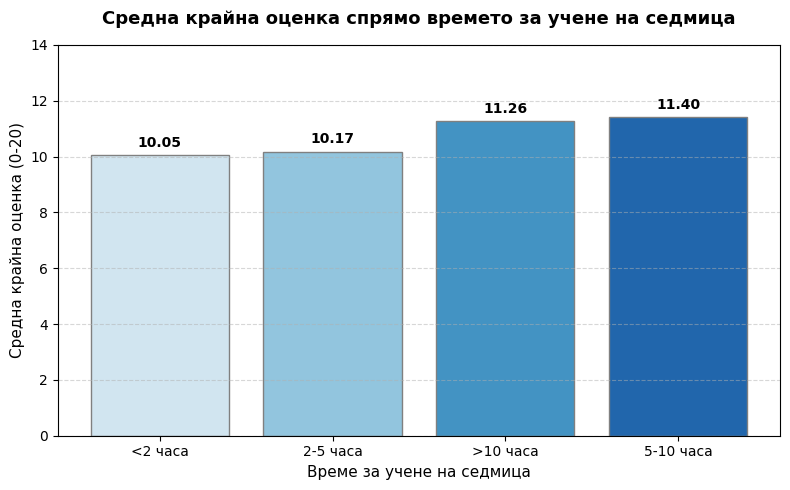

In [ ]:
# Пренапсиваме категориите
study_labels = {1: '<2 часа', 2: '2-5 часа', 3: '5-10 часа', 4: '>10 часа'}
df['studytime_bg'] = df['studytime'].map(study_labels)
# Средна крайна оценка по групи, сортираме
mean_g3_study = df.groupby('studytime_bg')['G3'].mean().reset_index()
mean_g3_study = mean_g3_study.sort_values(by='G3')
# Фигура, оси
fig, ax = plt.subplots(figsize=(8, 5))
colors_study = ['#d1e5f0', '#92c5de', '#4393c3', '#2166ac']

bars1 = ax.bar(mean_g3_study['studytime_bg'], mean_g3_study['G3'], color=colors_study, edgecolor='gray')
# Заглавия
ax.set_title('Средна крайна оценка спрямо времето за учене на седмица', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Време за учене на седмица', fontsize=11)
ax.set_ylabel('Средна крайна оценка (0-20)', fontsize=11)
ax.set_ylim(0, 14)
#  стойност над стълба
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.3,
            f'{height:.2f}', ha='center', fontsize=10, fontweight='bold')

ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Графиката потвърждава, че времето прекарано в подготовка има връзка с успеха. Учениците, които учат по-малко от 2 часа на седмица, показват най-ниски средни резултати 10.05. С увеличаването на времето за учене оценките растат, като най-високите са при тези, които отделят между 5 и 10 часа седмично 11.40.


Интересно е, че групата с над 10 часа учене има успех малко по-нисък от групата с 5-10 часа.
Това означава, че няма значение колко учиш, а колко ефективно го правиш.


---

**Потвърждаваме Хипотеза 4!** Отделяйки повече време за учене, учениците намаляват шанса си за провал и слаба оценка.

### Какво виждаме, когато погледнем всичко заедно?


Корелационна матрица

Избираме числовите колони за корелация

In [ ]:
num_cols = ['age', 'studytime', 'failures', 'goout',
    'Dalc','absences', 'G1', 'G2', 'G3']

corr_df = df[num_cols].copy()

Изчисляваме матрицата на корелация

In [ ]:
corr = corr_df.corr()

Heatmap

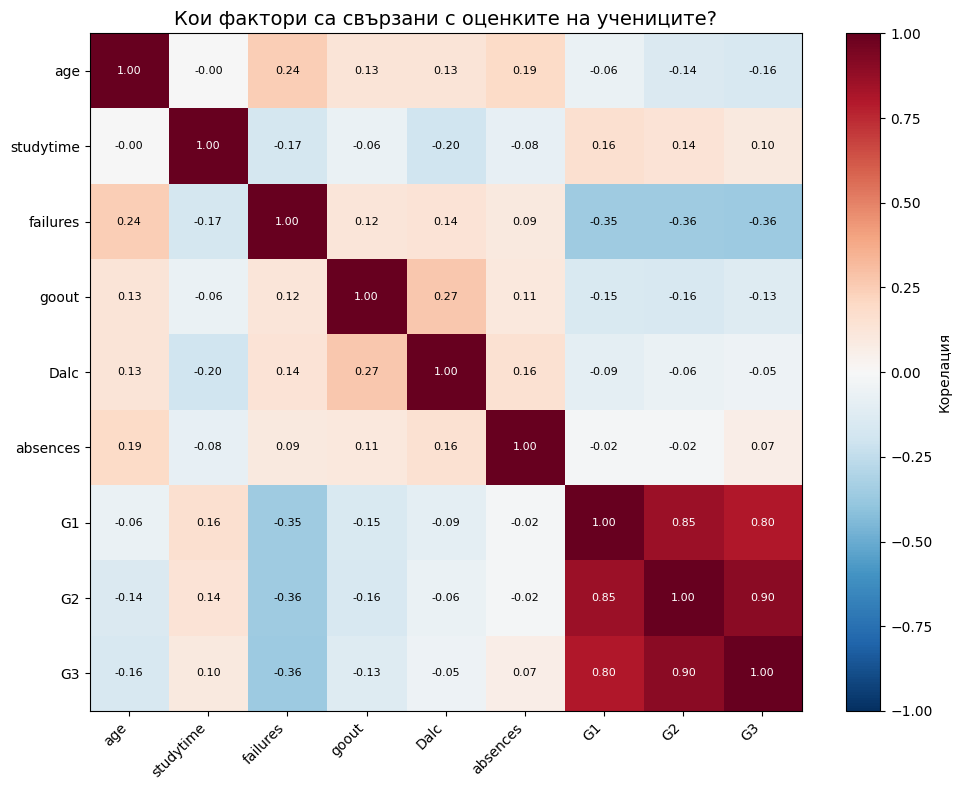

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
cols = corr.columns.tolist()
#цвят
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
#оси
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

# Добавяме нчисловите стойности във всяка клетка
for i in range(len(cols)):
    for j in range(len(cols)):
        val = corr.iloc[i, j]
        # Ако стойността е силна (над 0.5 или под -0.5), текстът става бял
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color='white' if abs(val) > 0.5 else 'black')

# Легенда и заглавие
plt.colorbar(im, ax=ax, label='Корелация')
ax.set_title('Кои фактори са свързани с оценките на учениците?', fontsize=14)

plt.tight_layout()
plt.show()


Забелязваме следните неща:

Учениците, които имат по-добри оценки през първия срок, зъвршват също с по-добри.

Колкото повече късания има един ученик, толкова по-ниски са му оценките.

Повечето часове учене на седмица, водят до по-добри резлутати.

Алкохолът и излизанията имат слаба отрицателна връзка с оценките, но помежду си е силна и положителна. Тези, които излизат повече, пият повече.

Въпрос: Може ли желанието за висше да влияе на крайната оценка?

/tmp/ipykernel_1336/3166569627.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_yes, data_no], labels=['Иска висше (Да)', 'Не желае висше (Не)'],


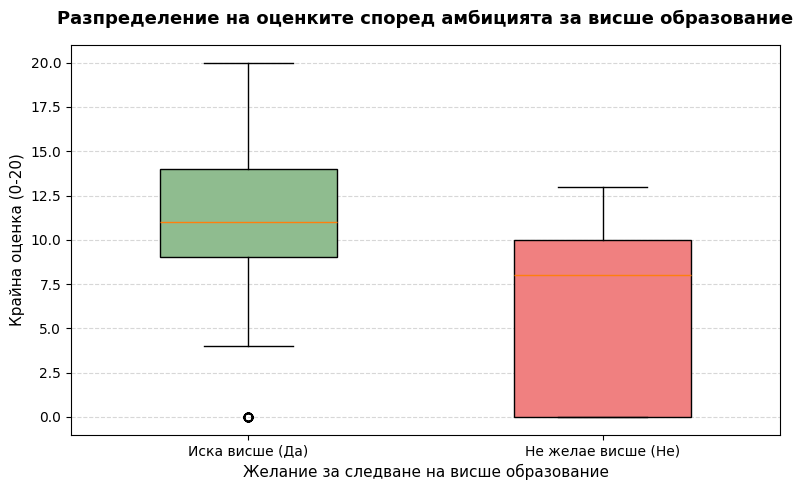

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
# Разделяме данните на да и не
data_yes = df[df['higher'] == 'yes']['G3']
data_no = df[df['higher'] == 'no']['G3']

bp = ax.boxplot([data_yes, data_no], labels=['Иска висше (Да)', 'Не желае висше (Не)'],
                patch_artist=True, widths=0.5)
#  Цветове
box_colors = ['darkseagreen', 'lightcoral']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)

ax.set_title('Разпределение на оценките според амбицията за висше образование', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Желание за следване на висше образование', fontsize=11)
ax.set_ylabel('Крайна оценка (0-20)', fontsize=11)

ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Тази диаграма показва най-голямата разлика в нашите данни. Учениците, които искат да завършат университет, имат медиана около 11 и максимален успех 20. При тези без желание за висше образование, цялата кутия е по-надолу, медианата е 8, под минимума.

Реално ако ученикът има амбиции за своето бъдеще, то той полага усилия, които водят до успех.

Въпрос: Какво влияние има социален живот през уикенда върху оценките?

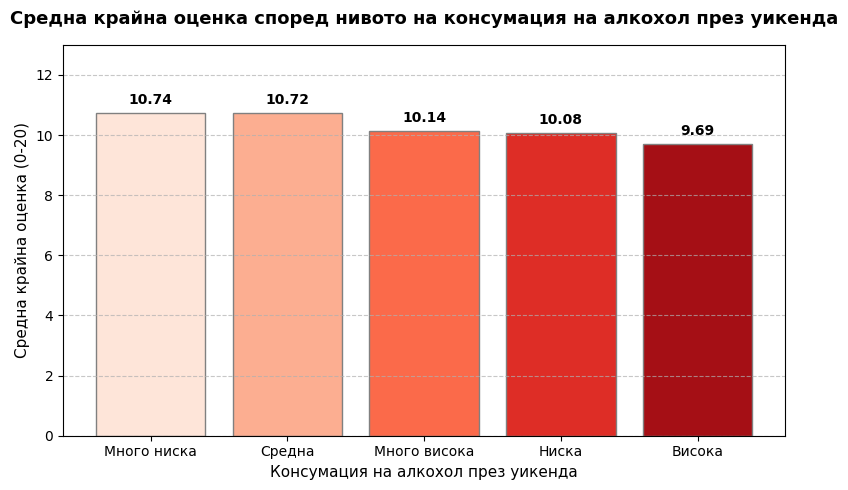

In [ ]:
# от 1 (много ниска) до 5 (много висока)
walc_labels = {1: 'Много ниска', 2: 'Ниска', 3: 'Средна', 4: 'Висока', 5: 'Много висока'}
df['walc_bg'] = df['Walc'].map(walc_labels)
# Изчисляваме средната оценка и сортираме
mean_g3_walc = df.groupby('walc_bg')['G3'].mean().reset_index()
mean_g3_walc = mean_g3_walc.sort_values(by='G3', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
red_colors = ['#fee5d9', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15']

bars4 = ax.bar(mean_g3_walc['walc_bg'], mean_g3_walc['G3'], color=red_colors, edgecolor='gray')

ax.set_title('Средна крайна оценка според нивото на консумация на алкохол през уикенда', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Консумация на алкохол през уикенда', fontsize=11)
ax.set_ylabel('Средна крайна оценка (0-20)', fontsize=11)
ax.set_ylim(0, 13)

for bar in bars4:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.3,
            f'{height:.2f}', ha='center', fontsize=10, fontweight='bold')

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Ниската до консумация води до най-високи оценки. Високата до другата крайност - най-ниски.
Изводът е, че не трябва да се злоупотребява и стига до крайности с алкохола.

Въпрос: Как се изменя успеха през сроковете?

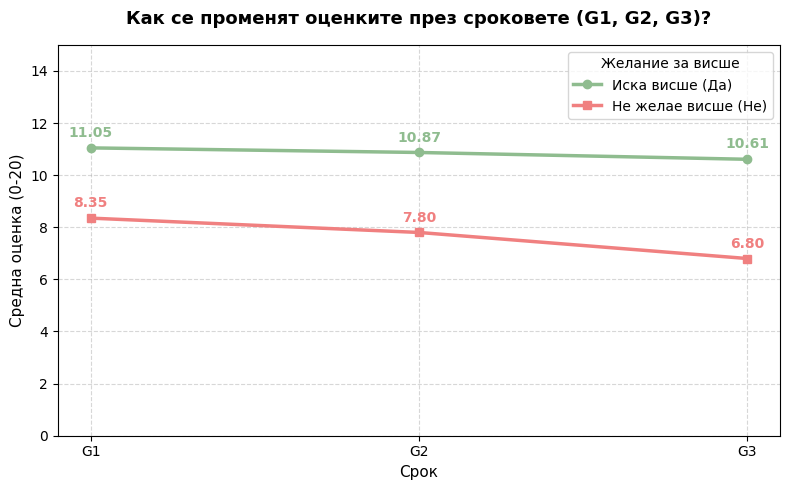

In [ ]:
# Средния успех по срокове за двете групи ученици
grades_trend = df.groupby('higher')[['G1', 'G2', 'G3']].mean().T

fig, ax = plt.subplots(figsize=(8, 5))

# линии
ax.plot(grades_trend.index, grades_trend['yes'], marker='o', linewidth=2.5, color='darkseagreen', label='Иска висше (Да)')
ax.plot(grades_trend.index, grades_trend['no'], marker='s', linewidth=2.5, color='lightcoral', label='Не желае висше (Не)')

for col in grades_trend.columns:
    color = 'darkseagreen' if col == 'yes' else 'lightcoral'
    for idx in grades_trend.index:
        val = grades_trend.loc[idx, col]
        ax.text(idx, val + 0.3, f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=color)

# Настройки на облика
ax.set_title('Как се променят оценките през сроковете (G1, G2, G3)?', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Срок', fontsize=11)
ax.set_ylabel('Средна оценка (0-20)', fontsize=11)
ax.set_ylim(0, 15)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Желание за висше', fontsize=10)

plt.tight_layout()

Забелязваме, че учениците, които искат висше имат по-високи резултати и ги задържат сравнително непроменени.
При останалите, които нямат желание, успехът е доста по-нисък и липсва прогрес.

## Част IV: Заключение и препоръки

### 4.1 Обобщение
След анализ на данните за оценките на учениците по математика, можем да направим следните изводи за хипотезите:

**Хипотеза 1 (Образование на родителите):** Не се потвърждава. Данните сочат, че учениците, чиито майки и бащи нямат висше образование, постигат най-висок среден успех. Майките, които не подкрепят децата си и нямат образование, водят до оценка Добър.

**Хипотеза 2 (Консумация на алкохол):** Не се потвърждава изцяло. Обратно на очакванията, че редовното пиене води до неуспех, учениците с най-висока консумация през седмицата  показват висок процент на преминали ученици (77.8%) и нямат много по-нисък успех в сравнение с другите. Алкохолът не е единственият фактор за ниски оценки.

**Хипотеза 3 (Отсъствия от училище):** Потвърждава се. Отсъствията са ключове, учениците с до 10 отсъствия имат почти двойно по-голям шанс за отлична оценка (10.9%) спрямо тези с над 10 отсъствия (6.1%).

**Хипотеза 4 (Време за самостоятелно учене):** Потвърждава се . Времето, прекарано над учебниците, има връзка с успеха. Учениците, които отделят под 2 часа седмично, имат средно по 0.52 скъсвания на изпити, докато тези, които учат над 10 часа, свеждат това до минимум (едва 0.04).

### 4.2 Неочаквани находки
**Без образование:** Децата, чиито родители имат нямат образование (0), показват висока средна оценка на финалния изпит G3 (13.00 за майките и 11.00 за бащите).
**Връзката между сроковете и крайната оценка:** Връзка между текущите оценки (G1, G2) и финалната оценка (G3) е голяма (над 0.80). Това означава, че крайното представяне е предсказуемо още в първите седмици на учебната година.

### 4.3 Препоръки
На базата на анализираните данни можем да предложим следните  мерки :
1. **Следена на отсъствията:** Училищата трябва да предупреждават веднага щом някой ученик има повече от 5-6 отсъствия, тъй като след 10-тото шансовете за успех спадат.
2. **Учене от поне 2-5 часа:** Организиране на консултации и занимални в самото училище, насочени към учениците, които признават, за да намалеят неуспехите.
3. **След първия изпит (G1):** Тъй като той предсказва крайния резултат, учениците със слаби оценки на G1 трябва да бъдат насърчавани да учат, преди дупките в знанията им да са се задълбочили.

### 4.4 Ограничения

* Dataset-ът обхваща ученици само от две конкретни училища в Португалия. Изводите не могат сляпо да се пренесат за образователната система в България или други страни.
* Някои групи (като родителите без образование или учениците с екстремен алкохолизъм) са от малък брой хора (под 5-10 души), което ги прави ненадеждни за заключения.
* Това, че учениците с повече отсъствия имат по-ниски оценки, не означава задължително, че самото физическо отсъствие е причината. Възможно е да има други причини.


---

*Този анализ е изготвен в Google Colab.*

*Dataset: [Student Performance Dataset](https://archive.ics.uci.edu/dataset/320/student+performance) (UCI Machine Learning Repository)*

